## The plot gives the number of transistors on a logarithmic scale. We are tasked with finding the least squares straight-line fit of the data using the following model:

$\log_{10} N \approx w_0 + w_1(t - 1970)$

where $(t)$ is the year and $(N)$ is the number of transistors.

We need to:

1. Find the coefficients $(w_0)$ and $(w_1)$ that minimize the mean squared error on the data.
2. Give the error on the data.
3. Plot the model you find along with the data points.
4. Use your model to predict the number of transistors in a microprocessor introduced in 2015.
5. Compare the prediction to the IBM Z13 microprocessor, released in 2015, which has around $(4 \times 10^9)$ transistors.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Given data from the table
years = np.array([1971, 1972, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2002, 2003])
transistors = np.array(
    [2250, 2500, 5000, 29000, 120000, 275000, 1180000, 3100000, 7500000, 24000000, 42000000, 220000000, 410000000])


the data is skewed

In [ ]:
# Convert transistors count to log scale
log_transistors = np.log10(transistors)

# Center the year data around 1970
years_centered = years - 1970

In [ ]:
log_transistors.shape

(13,)

In [ ]:
# Reshape the data to fit the model
X = years_centered.reshape(-1, 1)
y = log_transistors.reshape(-1, 1)
X.shape

(13, 1)

In [ ]:
# Create and train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
# Coefficients
theta_1 = model.intercept_
theta_2 = model.coef_
theta_1, theta_2

(array([3.12559263]), array([[0.15401818]]))

In [ ]:
# Predictions
predictions = model.predict(X)
predictions

array([[3.27961081],
       [3.43362899],
       [3.74166535],
       [4.35773807],
       [4.97381079],
       [5.43586533],
       [6.05193805],
       [6.66801077],
       [7.28408349],
       [7.59211985],
       [7.74613803],
       [8.05417439],
       [8.20819257]])

In [ ]:
# Calculate MS error
mean_squared_error(y, predictions)

0.04124014087055709

In [ ]:
#manual computations
#m = X.shape[0]
#ones = np.ones(m)
#A = np.column_stack((ones, X))
#xhat = la.solve(A.T @ A, A.T @ y)
#xhat

In [ ]:
# Predict the number of transistors in 2015
year_2015 = np.array([[2015 - 1970]])
log_transistors_2015 = model.predict(year_2015)
log_transistors_2015 # this is log_10 of N

array([[10.05641073]])

In [ ]:
transistors_2015 = 10 ** log_transistors_2015[0]
transistors_2015

array([1.13870369e+10])

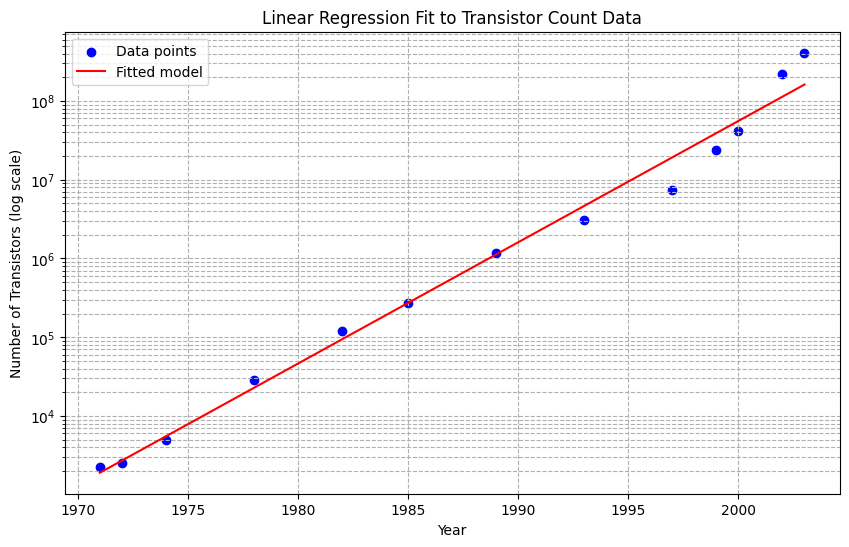

In [ ]:
# Plot the data points and the fitted model
plt.figure(figsize=(10, 6))
plt.scatter(years, transistors, color='blue', label='Data points')
plt.plot(years, 10 ** predictions, color='red', label='Fitted model')

# Set the scale of the y-axis to logarithmic
plt.yscale('log')

# Label the axes and the plot
plt.xlabel('Year')
plt.ylabel('Number of Transistors (log scale)')
plt.title('Linear Regression Fit to Transistor Count Data')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()